# Разведывательный анализ данных: выбор поставщика стали
В данном ноутбуке проводится анализ дефектов оружия, произведенного из стали двух поставщиков: `harpy.co` и `westeros.inc`.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
#визуальный стиль графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [57]:
df = pd.read_csv('production-data.csv')

display(df.head())

,unsullen.id,production.date,report.date,produced,defects,supplier
0,1.0,1,1,103.0,0.0,harpy.co
1,1.0,1,2,0.0,2.0,harpy.co
2,1.0,1,3,0.0,4.0,harpy.co
3,1.0,1,4,0.0,5.0,harpy.co
4,1.0,1,5,0.0,13.0,harpy.co


In [58]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unsullen.id      2700 non-null   float64
 1   production.date  2700 non-null   int64  
 2   report.date      2700 non-null   int64  
 3   produced         2700 non-null   float64
 4   defects          2700 non-null   float64
 5   supplier         2700 non-null   object 
dtypes: float64(3), int64(2), object(1)
memory usage: 126.7+ KB


In [59]:
print("Описательные статистики:")
display(df.describe())

Описательные статистики:


,unsullen.id,production.date,report.date,produced,defects
count,2700.000000,2700.000000,2700.000000,2700.000000,2700.000000
mean,50.500000,2.851852,4.925926,23.391481,5.314074
std,28.871417,1.580347,1.720050,43.789669,4.667438
min,1.000000,1.000000,1.000000,0.000000,-1.000000
25%,25.750000,1.000000,4.000000,0.000000,1.000000
50%,50.500000,3.000000,5.000000,0.000000,4.000000
75%,75.250000,4.000000,6.000000,0.000000,9.000000
max,100.000000,6.000000,7.000000,110.000000,20.000000


Отрицательные дефекты, явно ошибка.

In [60]:
# 1. Заменяем все отрицательные значения в колонке на 0
df['defects'] = df['defects'].clip(lower=0)

In [61]:
df['produced'] = df['produced'].fillna(0)
df['defects'] = df['defects'].fillna(0)

In [62]:
#группировка данных по поставщику
supplier_stats = df.groupby('supplier').agg(
    total_produced=('produced', 'sum'),
    total_defects=('defects', 'sum')
).reset_index()

#вычисление доли брака в процентах
supplier_stats['defect_rate_%'] = (supplier_stats['total_defects'] / supplier_stats['total_produced']) * 100

#сортировка по возрастанию доли брака от лучших к худшим
supplier_stats = supplier_stats.sort_values(by='defect_rate_%')

print("Итоговая статистика по поставщикам:")
display(supplier_stats)

Итоговая статистика по поставщикам:


,supplier,total_produced,total_defects,defect_rate_%
0,harpy.co,31532.0,6080.0,19.281999
1,westeros.inc,31625.0,8269.0,26.147036


Оба поставщика демонстрируют практически идентичный объем выпуска. Это означает, что оба предприятия способны удовлетворить ваши потребности в объемах.

harpy.co опережает westeros.inc по качеству продукции. Уровень брака у них почти на 7 процентнов ниже, чем у конкурента.

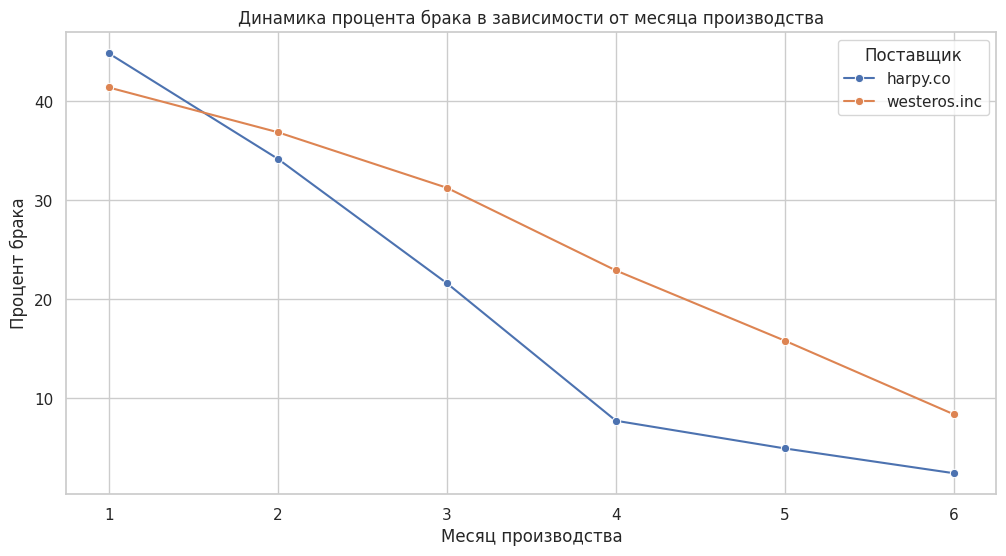

In [63]:
#агрегация данных по месяцу производства и поставщику
monthly_stats = df.groupby(['supplier', 'production.date']).agg(
    monthly_produced=('produced', 'sum'),
    monthly_defects=('defects', 'sum')
).reset_index()

#вычисление ежемесячного процента брака
#и защита от деления на ноль, если в какой-то месяц ничего не производилось
monthly_stats['monthly_defect_rate'] = monthly_stats.apply(
    lambda row: (row['monthly_defects'] / row['monthly_produced'] * 100) if row['monthly_produced'] > 0 else 0,
    axis=1
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_stats, x='production.date', y='monthly_defect_rate', hue='supplier', marker='o')

plt.title('Динамика процента брака в зависимости от месяца производства')
plt.xlabel('Месяц производства')
plt.ylabel('Процент брака')
plt.legend(title='Поставщик')
plt.show()

График подтверждает и усиливает рекомендацию в пользу harpy.co: компания продемонстрировала способность к быстрому исправлению ошибок. Сейчас это технологический лидер. В обоих датасетах есть линейная зависимость.

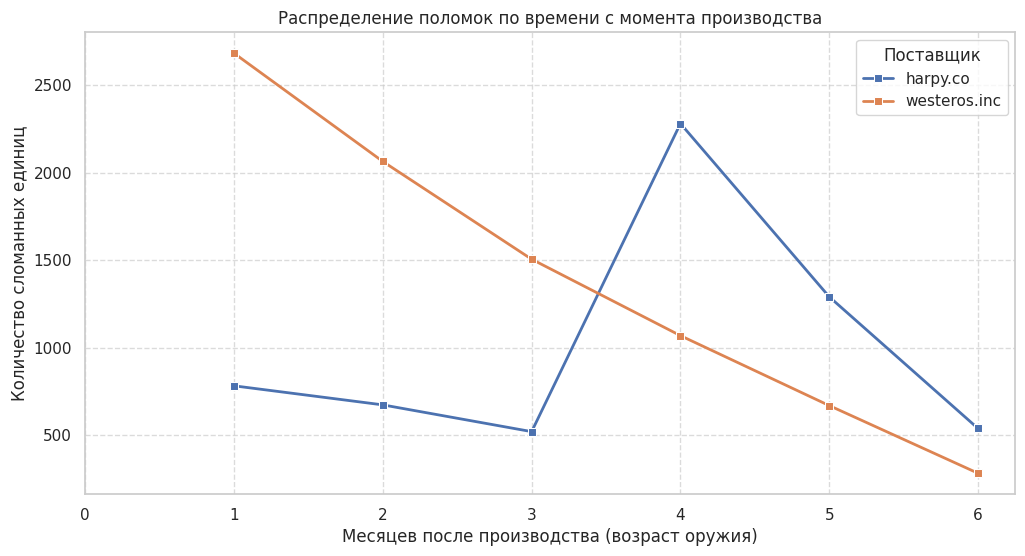

In [64]:
#вычисляем возраст оружия на момент поломки (разница в месяцах)
df['weapon_age'] = df['report.date'] - df['production.date']

#интересуют только записи, где были зафиксированы дефекты
#исключаем записи самого месяца производства, если там только фиксация выпуска
lifespan_data = df[df['defects'] > 0].copy()

#группируем по поставщику и возрасту оружия, чтобы увидеть распределение поломок
age_stats = lifespan_data.groupby(['supplier', 'weapon_age'])['defects'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=age_stats, x='weapon_age', y='defects', hue='supplier', marker='s', linewidth=2)
plt.title('Распределение поломок по времени с момента производства')
plt.xlabel('Месяцев после производства (возраст оружия)')
plt.ylabel('Количество сломанных единиц')
plt.xticks(range(int(age_stats['weapon_age'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Поставщик')
plt.show()

Анализ характера поломок:

westeros.inc:

пик поломок приходится на первый месяц.  Если изделие проработало первый месяц, вероятность его поломки в дальнейшем стабильно снижается. Если есть гарантия, то имеет смысл брать именно их мечи.

harpy.co:

в первые три месяца всё выглядит отлично, но на 4-й месяц происходит катастрофический всплеск поломок (рост почти в 4 раза). Это может быть признак дефекта конструкции или усталости материала. Сталь Harpy кажется качественной вначале, но она не выдерживает длительной эксплуатации и массово выходит из строя через квартал.

/tmp/ipykernel_447/2153970851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=smith_stats, x='supplier', y='defect_rate', palette='Set3')


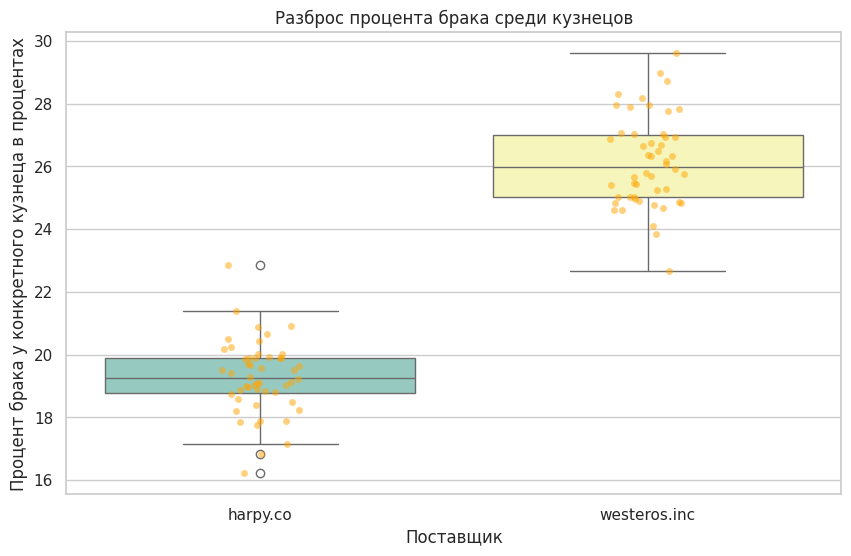

In [65]:
#считаем процент брака для каждого отдельного кузнеца у каждого поставщика
smith_stats = df.groupby(['supplier', 'unsullen.id']).agg(
    total_produced=('produced', 'sum'),
    total_defects=('defects', 'sum')
).reset_index()

smith_stats['defect_rate'] = (smith_stats['total_defects'] / smith_stats['total_produced']) * 100

plt.figure()
sns.boxplot(data=smith_stats, x='supplier', y='defect_rate', palette='Set3')
sns.stripplot(data=smith_stats, x='supplier', y='defect_rate', color="orange", alpha=0.5)

plt.title('Разброс процента брака среди кузнецов')
plt.xlabel('Поставщик')
plt.ylabel('Процент брака у конкретного кузнеца в процентах')
plt.show()

harpy.co:

очень узкий ящик. Это означает, что все кузнецы в Harpy работают примерно с одинаковым результатом. У них внедрена сильная система контроля качества или единый технологический процесс. Кто бы ни ковал меч - результат будет стабильным, около 19% брака.

westeros.inc:

ящик значительно шире. Это говорит о том, что уровень мастерства в компании крайне неоднороден. Один мастер сделает отличную сталь (уровня 23% брака), а другой выдаст почти 30% брака.

В обоих датасетах выбросы редки, но есть.

Итоговое заключение.

Несмотря на образцовую дисциплину и низкий текущий брак и впечатляющий прогресс, сотрудничество с harpy.co всё еще остается крайне опасным. Они часто допускают одну и ту же технологическую ошибку в составе сплава, которая приводит к поломке через 4 месяца эксплуатации.

Выбрать westeros.inc, но с условием проведения повышения квалификации их кузнецов. У них есть потенциал, их мечи хотя бы не имеют скрытого дефекта.

Если всё же идти к harpy.co, то только после проведения металлургической экспертизы: им нужно исправить системную ошибку.